In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
filepath = '../benchmark_datasets/CACHE5/20240430_MCHR1_splitted_RJ.csv'
df = pd.read_csv(filepath, index_col=0)
df.head()
from rdkit import Chem
def compute_heavy_atom_count(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol.GetNumHeavyAtoms() if mol else None

df["HAC"] = df["smiles"].apply(compute_heavy_atom_count)

In [4]:
positive_labels = df[df["class"] == 1]
positive_labels

,aid,cid,acname,smiles,exp_type,source,acvalue_uM,class,ID,random_10f,DataSAIL_10f,HAC
Unnamed: 0,,,,,,,,,,,,
0,262800,10128900,pKi,CN1CCN(CCCCN(C(=O)Nc2ccc(F)c(C(F)(F)F)c2)[C@@H...,displacement,patent,8.657577,1,ID00000,Fold_0,Fold_9,40
1,262800,10174940,pKi,N#Cc1cccc([C@]23CC[C@@H](N(CCCCN4CCCCC4)C(=O)N...,displacement,patent,8.795880,1,ID00001,Fold_8,Fold_9,39
2,262800,10195637,pKi,N#Cc1cccc([C@]23CC[C@@H](N(CCN4CCCCC4)C(=O)Nc4...,displacement,patent,8.387216,1,ID00002,Fold_8,Fold_9,34
4,262800,10239907,pKi,CC(C)CN1CCN(CCN(C(=O)Nc2ccc(F)c(C(F)(F)F)c2)[C...,displacement,patent,8.045757,1,ID00004,Fold_8,Fold_9,41
5,262800,10289615,pKi,N#Cc1cccc([C@]23CC[C@@H](N(CCCCN4CCOCC4)C(=O)N...,displacement,patent,8.602060,1,ID00005,Fold_8,Fold_9,39
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,19288562,CHEMBL4410510,pIC50,CN(C)CCC(CNC(=O)Nc1cc(F)cc(F)c1)c1ccc(-c2cccc(...,antagonist activity,chembl,6.055517,1,ID02995,Fold_0,Fold_5,33
2996,19288563,CHEMBL4410510,pIC50,CN1CCC(CNC(=O)Nc2ccccc2)(c2ccc(-c3cccc(C#N)c3)...,antagonist activity,chembl,5.657577,1,ID02996,Fold_8,Fold_5,32
2997,19288565,CHEMBL4410510,pIC50,CN(C)CCC(CNC(=O)Nc1ccccc1)c1ccc(-c2cccc(C#N)c2...,antagonist activity,chembl,5.585027,1,ID02997,Fold_0,Fold_5,31


/tmp/ipykernel_1948762/3237406194.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(positive_labels['acvalue_uM'],shade=True)


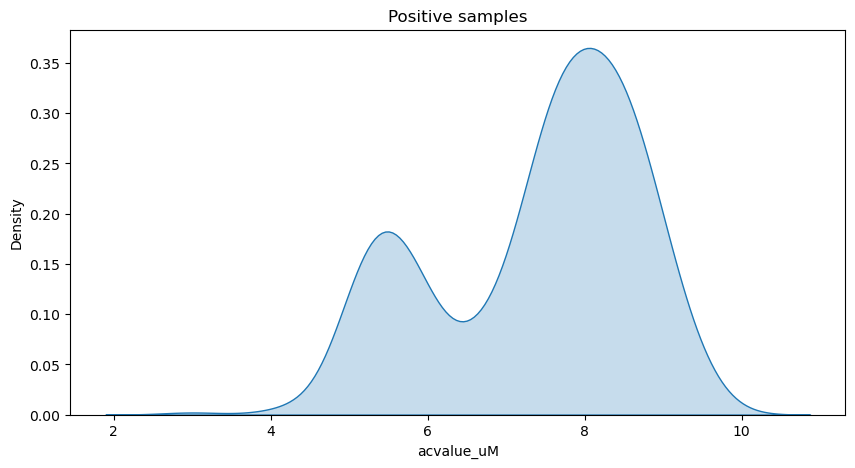

Max ac_Value =  9.769551078621726


In [5]:
plt.figure(figsize=(10,5))
plt.xlabel('acvalue_uM')
plt.ylabel('Density')
sns.kdeplot(positive_labels['acvalue_uM'],shade=True)
plt.title("Positive samples")
plt.show()

print("Max ac_Value = ", positive_labels['acvalue_uM'].max())

/tmp/ipykernel_1948762/2270717806.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(neg_df['acvalue_uM'],shade=True)


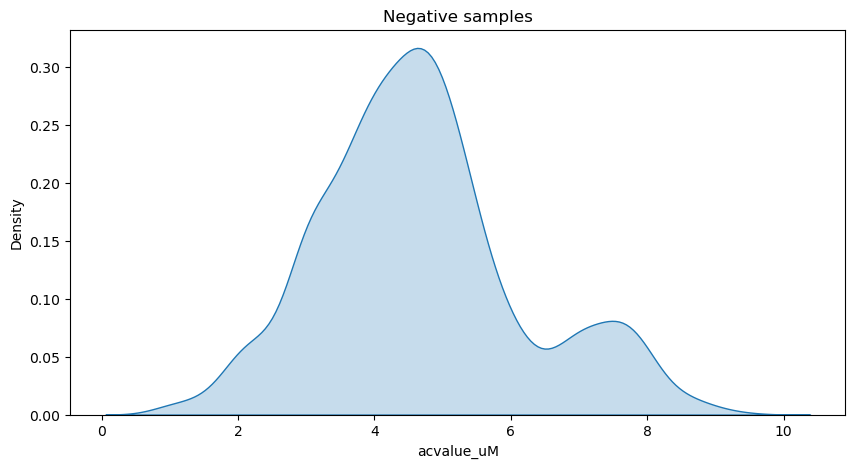

Max ac_Value =  9.443697499232712


In [6]:
neg_df = df[df["class"] != 1]
plt.figure(figsize=(10,5))
plt.xlabel('acvalue_uM')
plt.ylabel('Density')
sns.kdeplot(neg_df['acvalue_uM'],shade=True)
plt.title("Negative samples")
plt.show()

print("Max ac_Value = ", neg_df['acvalue_uM'].max())

/tmp/ipykernel_1948762/2465716919.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['acvalue_uM'],shade=True)


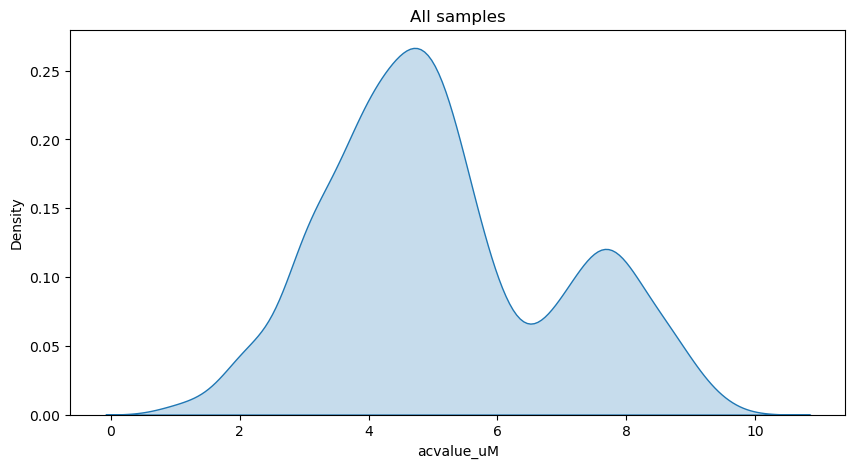

In [7]:
plt.figure(figsize=(10,5))
plt.xlabel('acvalue_uM')
plt.ylabel('Density')
sns.kdeplot(df['acvalue_uM'],shade=True)
plt.title("All samples")
plt.show()

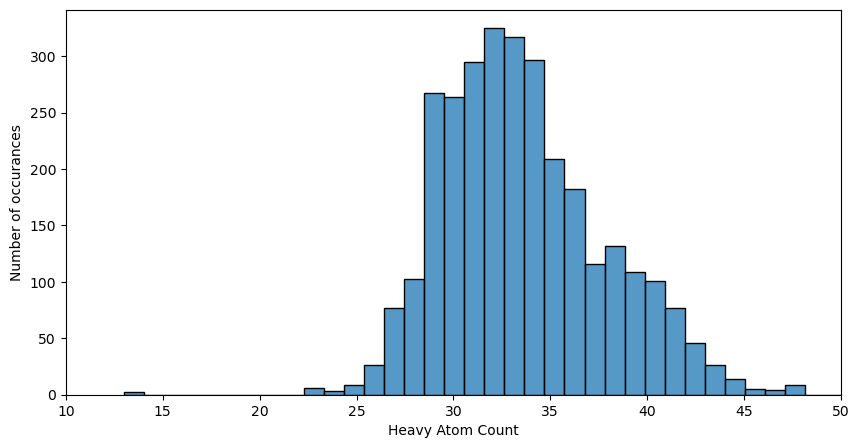

In [8]:
plt.figure(figsize=(10,5))
plt.xlim(10,50)
plt.xlabel('Heavy Atom Count')
plt.ylabel('Number of occurances')
sns.histplot(df['HAC'], bins = 150, kde=False)
plt.show()

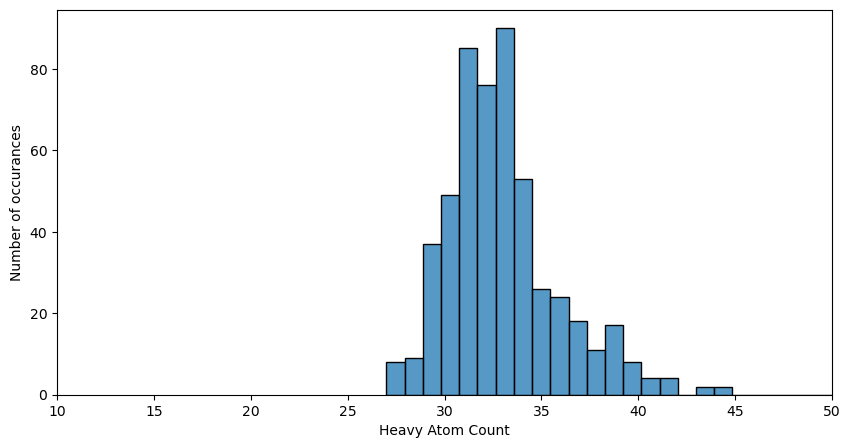

In [9]:
plt.figure(figsize=(10,5))
plt.xlim(10,50)
plt.xlabel('Heavy Atom Count')
plt.ylabel('Number of occurances')
sns.histplot(positive_labels['HAC'], bins = 150, kde=False)
plt.show()

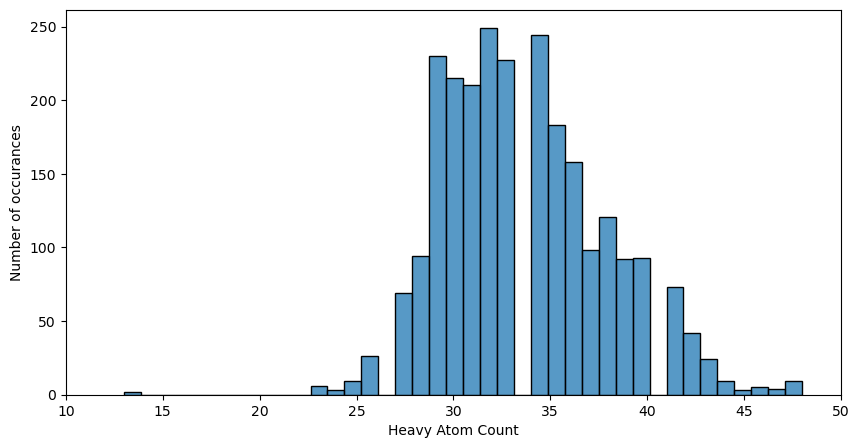

In [10]:
plt.figure(figsize=(10,5))
plt.xlim(10,50)
plt.xlabel('Heavy Atom Count')
plt.ylabel('Number of occurances')
sns.histplot(neg_df['HAC'], kde=False)
plt.show()

In [11]:
df["HAC"].mean(), df["HAC"].std()

(33.56911375661376, 5.869897055364571)

In [12]:
33 + (1.9*5.8), 33 - (1.9*5.8) 

(44.019999999999996, 21.98)

In [13]:
from scipy.stats import sem, t
from scipy.stats import norm
hac_data = df["HAC"]
# Calculate the mean
# Compute statistics
mean_hac = np.mean(hac_data)
std_hac = np.std(hac_data, ddof=1)  # Sample standard deviation
n = len(hac_data)

# Compute 95% confidence interval
z_critical = norm.ppf(0.975)  # Z-critical value for 95% confidence
margin_of_error = z_critical * (std_hac / np.sqrt(n))
lower_bound = mean_hac - margin_of_error
upper_bound = mean_hac + margin_of_error

print(f"Mean HAC: {mean_hac:.2f}")
print(f"95% Confidence Interval for HAC: ({lower_bound:.2f}, {upper_bound:.2f})")

Mean HAC: 33.57
95% Confidence Interval for HAC: (33.36, 33.78)


In [14]:
hac_data

Unnamed: 0
0       40
1       39
2       34
3       34
4       41
        ..
3019    23
3020    23
3021    23
3022    29
3023    27
Name: HAC, Length: 3024, dtype: int64

In [15]:
df['smiles']

Unnamed: 0
0       CN1CCN(CCCCN(C(=O)Nc2ccc(F)c(C(F)(F)F)c2)[C@@H...
1       N#Cc1cccc([C@]23CC[C@@H](N(CCCCN4CCCCC4)C(=O)N...
2       N#Cc1cccc([C@]23CC[C@@H](N(CCN4CCCCC4)C(=O)Nc4...
3       N#Cc1cccc([C@]23CC[C@@H](N(CCN4CC[C@@H](O)C4)C...
4       CC(C)CN1CCN(CCN(C(=O)Nc2ccc(F)c(C(F)(F)F)c2)[C...
                              ...                        
3019                 O=C(NC1CCN(Cc2ccccc2)CC1)c1ccc(F)cc1
3020                 O=C(NC1CCN(Cc2ccccc2)CC1)c1ccc(F)cc1
3021                 O=C(NC1CCN(Cc2ccccc2)CC1)c1ccc(F)cc1
3022    COc1cc(OC)cc(C(=O)N[C@@H]2CCN(Cc3ccc4ccccc4c3)...
3023    COc1cc(OC)cc(C(=O)N[C@@H]2CCN(C/C=C/c3ccccc3)C...
Name: smiles, Length: 3024, dtype: object

## Summary Statistics for acvalue_uM Differences in Repeated SMILES

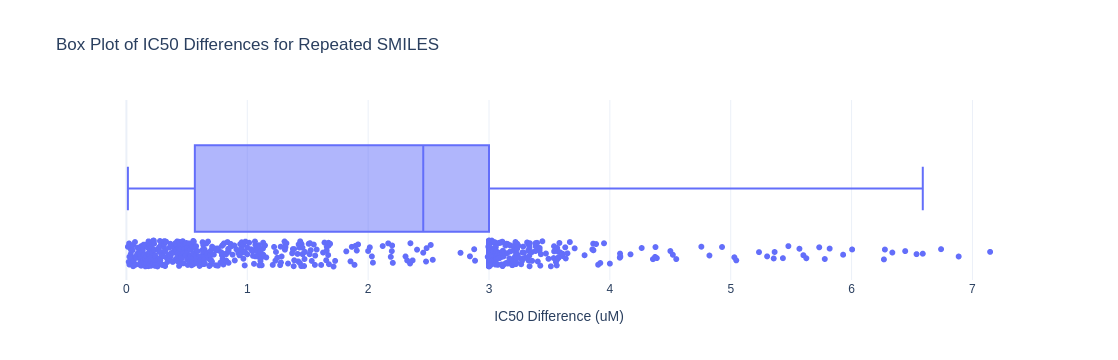

In [17]:
# Calculate the difference in 'acvalues_uM' for repeated smiles
repeated_smiles_ic50 = df.groupby('smiles').agg({'acvalue_uM': lambda x: x.max() - x.min()}).reset_index()
repeated_smiles_ic50 = repeated_smiles_ic50[repeated_smiles_ic50['acvalue_uM'] > 0]

# Summary statistics
summary_stats = repeated_smiles_ic50['acvalue_uM'].describe()

import plotly.express as px

# Create a horizontal box plot for IC50 differences
fig_box_horizontal = px.box(
    repeated_smiles_ic50,
    x='acvalue_uM',
    title='Box Plot of IC50 Differences for Repeated SMILES',
    labels={'acvalue_uM': 'IC50 Difference (uM)'},
    template='plotly_white',
    points='all'  # Show all points for detailed distribution
)

fig_box_horizontal.update_layout(
    xaxis_title="IC50 Difference (uM)",
    yaxis_title="",
    showlegend=False
)
fig_box_horizontal.show()


## Contradicting class Values in Repeated SMILES

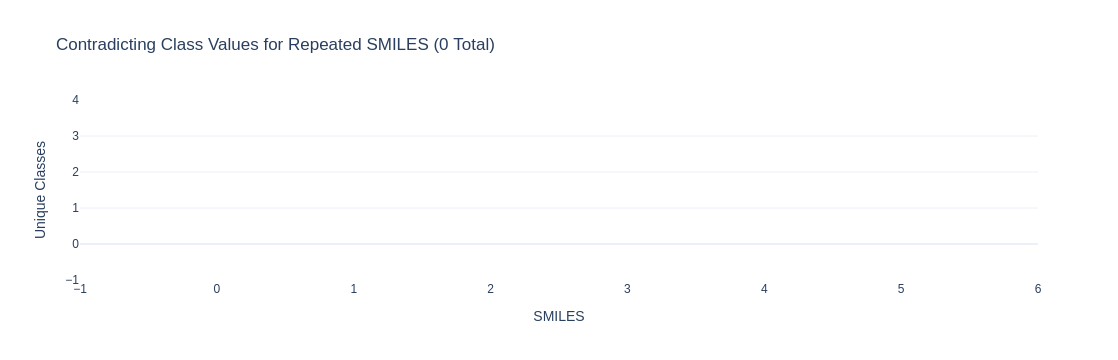

Total SMILES with contradicting class values: 0


In [18]:
# Count the number of unique 'class' values for each SMILES
contradicting_classes = df.groupby('smiles')['class'].nunique().reset_index()
contradicting_classes = contradicting_classes[contradicting_classes['class'] > 1]

# Count total SMILES with contradicting class
total_contradictions = len(contradicting_classes)

# Bar chart of counts
fig_class = px.bar(
    contradicting_classes,
    x='smiles',
    y='class',
    title=f'Contradicting Class Values for Repeated SMILES ({total_contradictions} Total)',
    labels={'class': 'Number of Unique Classes', 'smiles': 'SMILES'},
    template='plotly_white',
)
fig_class.update_layout(xaxis_title="SMILES", yaxis_title="Unique Classes")
fig_class.show()

# Print summary
print(f"Total SMILES with contradicting class values: {total_contradictions}")


## Variatin in exp_type in repeated smiles

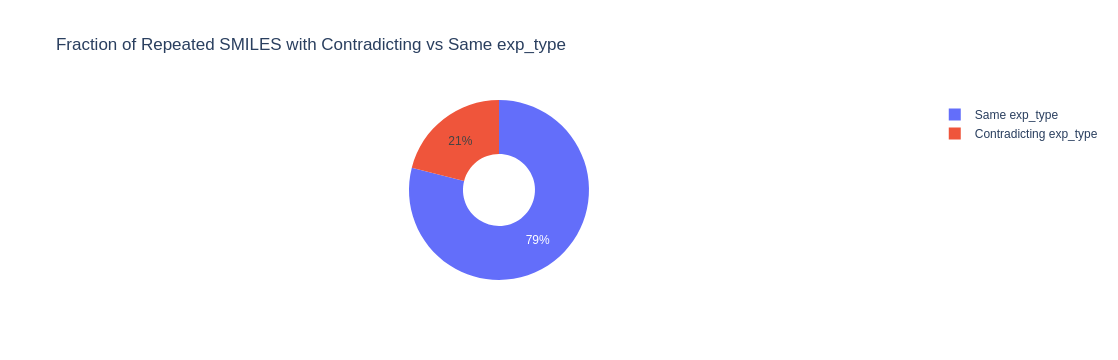

In [23]:
# Count unique exp_type values per SMILES
contradictions = df.groupby('smiles')['exp_type'].nunique().reset_index()
contradictions.columns = ['smiles', 'unique_exp_type_count']

# Identify contradictory SMILES (more than one unique exp_type)
contradictions['is_contradictory'] = contradictions['unique_exp_type_count'] > 1

# Compute fractions
total_repeated_smiles = len(contradictions)
fraction_contradictory = contradictions['is_contradictory'].mean()
fraction_same = 1 - fraction_contradictory

# Plot fractions
import plotly.express as px

fig_fraction = px.pie(
    names=['Contradicting exp_type', 'Same exp_type'],
    values=[fraction_contradictory * 100, fraction_same * 100],
    title="Fraction of Repeated SMILES with Contradicting vs Same exp_type",
    hole=0.4,  # Donut chart
    template='plotly_white',
    labels={'value': 'Fraction (%)'}
)
fig_fraction.show()


### What is the distribution of exp_type categories among repeated SMILES with contradictory exp_type values? It highlights the percentage of occurrences for each exp_type within the subset of repeated SMILES exhibiting contradictions.

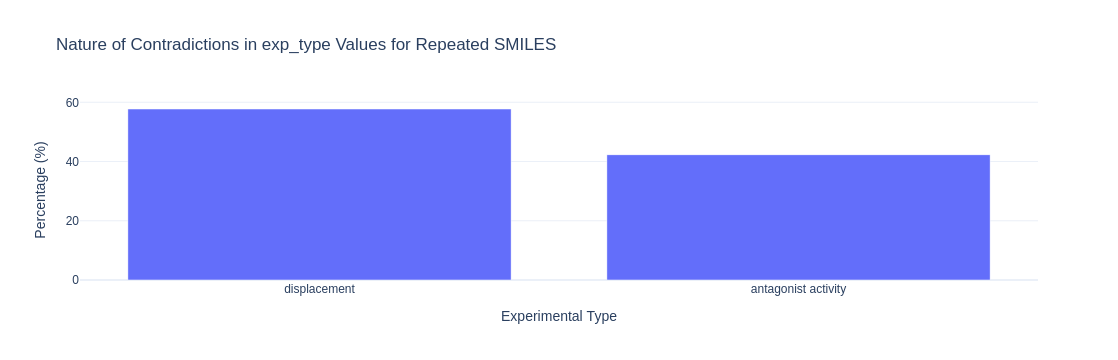

In [24]:
# Filter SMILES with contradictory exp_type
contradictory_smiles = df[df['smiles'].isin(
    contradictions[contradictions['is_contradictory']]['smiles']
)]

# Count occurrences of each exp_type for contradictory SMILES
contradictory_exp_type = contradictory_smiles['exp_type'].value_counts(normalize=True) * 100
contradictory_exp_type = contradictory_exp_type.reset_index()
contradictory_exp_type.columns = ['exp_type', 'percentage']

# Plot distribution of contradictory exp_type
fig_contradiction_nature = px.bar(
    contradictory_exp_type,
    x='exp_type',
    y='percentage',
    title='Nature of Contradictions in exp_type Values for Repeated SMILES',
    labels={'exp_type': 'Experimental Type', 'percentage': 'Percentage (%)'},
    template='plotly_white'
)
fig_contradiction_nature.show()


In [22]:
# Print summary statistics for unique exp_type counts
exp_type_summary = exp_type_analysis['unique_exp_type_count'].describe()
print(exp_type_summary)


count    350.0
mean       2.0
std        0.0
min        2.0
25%        2.0
50%        2.0
75%        2.0
max        2.0
Name: unique_exp_type_count, dtype: float64


## Repetition analysis by class

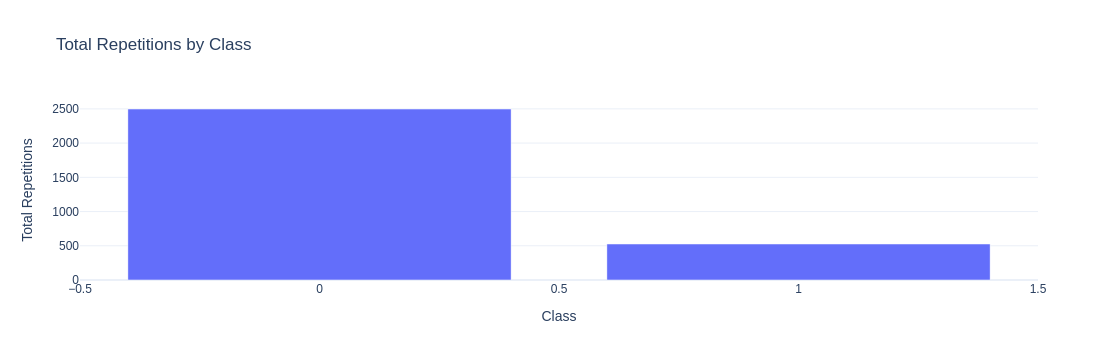

   class  total_repetitions  mean_repetition
0      0               2498         1.784286
1      1                526         1.984906


In [26]:
# Group by 'class' and calculate the total and mean repetitions
class_repetition = df.groupby('class').size().reset_index(name='total_repetitions')
class_repetition['mean_repetition'] = df.groupby('class')['smiles'].apply(lambda x: x.value_counts().mean()).values

# Bar chart for repetitions by class
fig_class_rep = px.bar(
    class_repetition,
    x='class',
    y='total_repetitions',
    title='Total Repetitions by Class',
    labels={'total_repetitions': 'Total Repetitions', 'class': 'Class'},
    template='plotly_white',
)
fig_class_rep.update_layout(xaxis_title="Class", yaxis_title="Total Repetitions")
fig_class_rep.show()

# Print summary
print(class_repetition)